# 01 — The Mean

## What is the mean?

The **mean** (arithmetic average) is the single number that best represents
the "centre" of a dataset. Intuitively, it is where the data would balance
if you placed each value on a see-saw.

### Formula

$$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i$$

- $n$ = number of data points  
- $x_i$ = each individual value  
- $\bar{x}$ ("x-bar") = the mean

### Why do we care?

The mean is the foundation of almost every statistical technique you will
encounter in machine learning:

* Centering data (subtract the mean → zero mean)
* Loss functions (MSE is a mean of squared errors)
* Normalization (z-score, RevIN) all use the mean

---

In [50]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
from utils.ml_utils import calculate_mean
from utils.plotting import plot_histogram

## Load the data

In [51]:
df = pd.read_csv('../data/fundamentals_data.csv')
df.head()

,student_score,temperature,sales,stock_price
0,78.0,23.6,330,157.51
1,70.3,20.1,450,160.39
2,79.8,18.6,459,129.60
3,90.3,25.1,404,156.97
4,69.2,27.2,481,158.79


## Step 1 — Manual calculation

Let's compute the mean of `student_score` step by step.

In [52]:
scores = df['student_score'].values

total = sum(scores)          # sum all values
n     = len(scores)          # count them
mean_manual = total / n

print(f'Sum          : {total:.1f}')
print(f'Count (n)    : {n}')
print(f'Mean (manual): {mean_manual:.2f}')

Sum          : 3465.0
Count (n)    : 50
Mean (manual): 69.30


## Step 2 — Using NumPy and our helper

In [53]:
mean_numpy  = np.mean(scores)
mean_custom = calculate_mean(scores)

print(f'numpy mean  : {mean_numpy:.2f}')
print(f'custom mean : {mean_custom:.2f}')
print(f'All agree   : {np.isclose(mean_manual, mean_numpy)}')

numpy mean  : 69.30
custom mean : 69.30
All agree   : True


## Step 3 — Visualise

The red dashed line marks the mean. Notice how it sits at the "centre of mass".

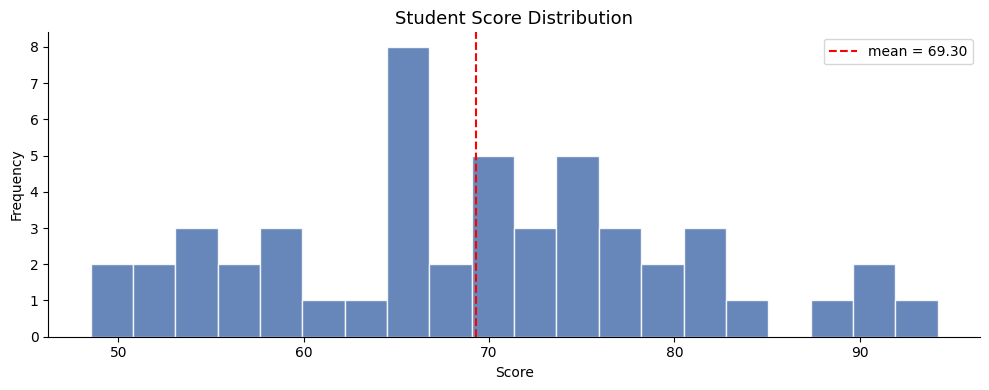

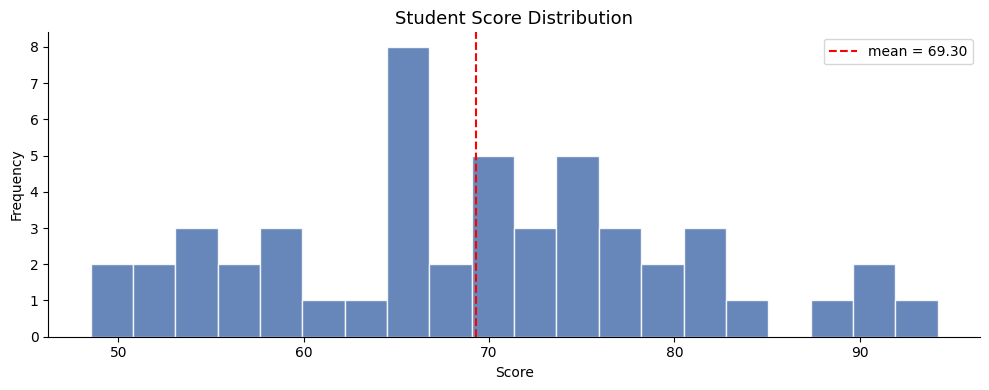

In [54]:
plot_histogram(scores, title='Student Score Distribution', xlabel='Score', show_mean=True)

## Step 4 — Means for all columns

In [55]:
for col in df.columns:
    print(f'{col:<15} mean = {calculate_mean(df[col].values):.2f}')

student_score   mean = 69.30
temperature     mean = 22.10
sales           mean = 495.34
stock_price     mean = 152.52


## Step 5 — Centering (subtracting the mean)

Subtracting the mean shifts the distribution so it is centred on **zero**.
This is the first step in normalization.

Mean of original : 69.30
Mean of centered : -0.000000  (≈ 0)


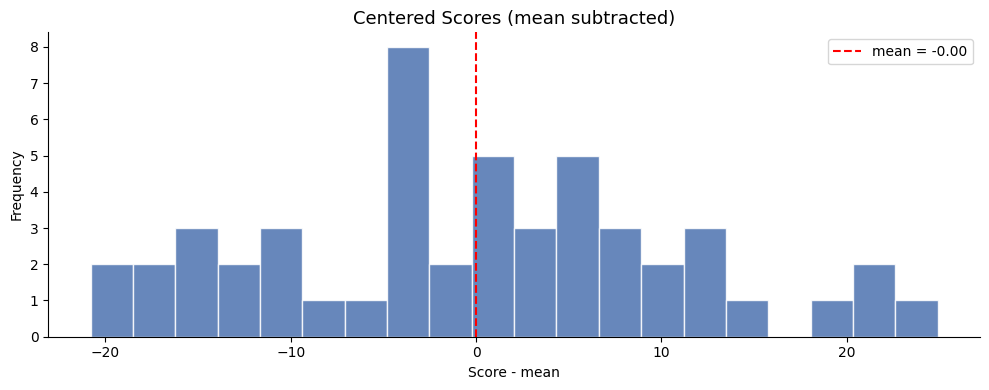

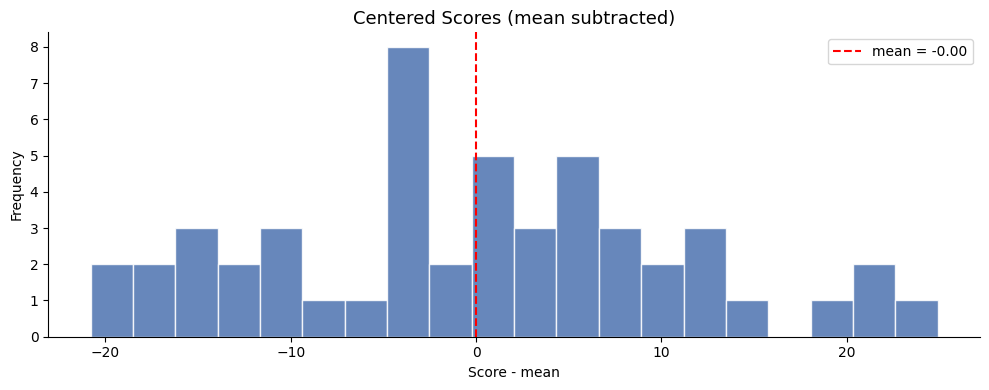

In [56]:
centered = scores - calculate_mean(scores)
print(f'Mean of original : {calculate_mean(scores):.2f}')
print(f'Mean of centered : {calculate_mean(centered):.6f}  (≈ 0)')   

plot_histogram(centered, title='Centered Scores (mean subtracted)', xlabel='Score - mean', show_mean=True)

---
## Exercises

1. Compute the mean of `temperature` manually (without NumPy). Verify with `calculate_mean`.
2. What happens to the mean if you multiply every score by 2?
   Predict first, then check in code.
3. The mean is sensitive to outliers. Add `scores = np.append(scores, 999)` and
   recompute the mean. How much does it change?

---
**Next notebook →** `02_variance_basics.ipynb` — measuring spread around the mean.

## Solution

In [57]:
# 1. compute the mean of temperature
temperature_data = df['temperature']
temperature_sum = sum(temperature_data)
total_number = len(temperature_data)

temperature_sum, total_number

mean = temperature_sum / total_number
print(f'Manually Computed Mean: {mean:.2f}')
print(f'Mean computed using function {calculate_mean(temperature_data):.2f}')

Manually Computed Mean: 22.10
Mean computed using function 22.10


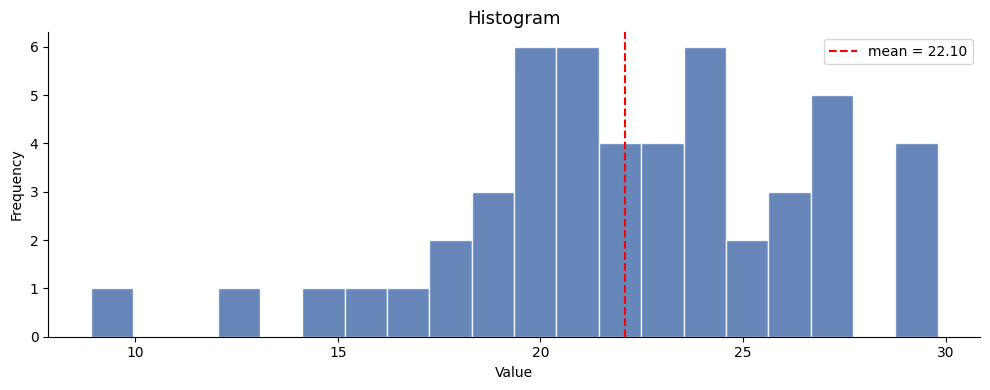

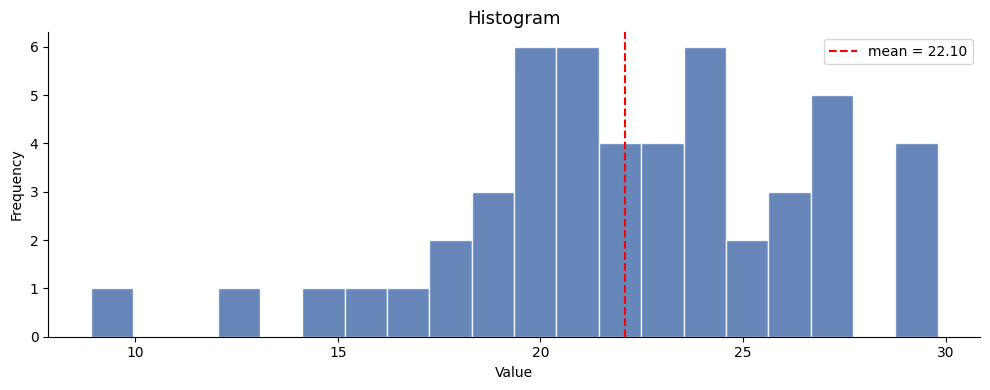

In [58]:
plot_histogram(temperature_data)

In [59]:
temperature_score = temperature_data * 2

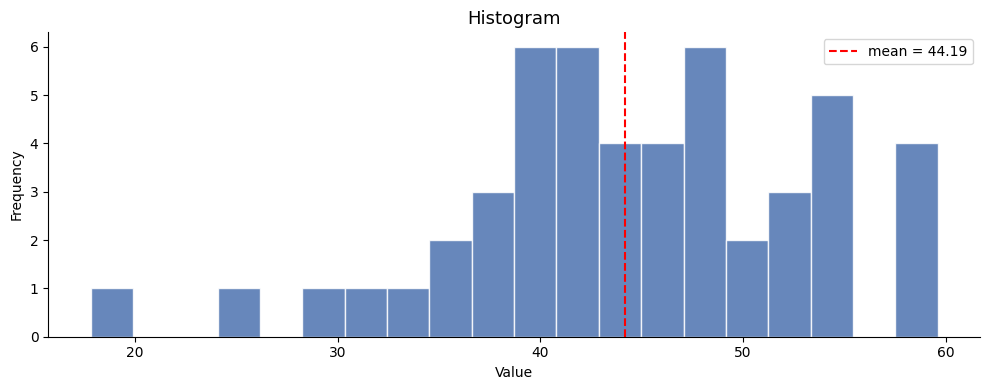

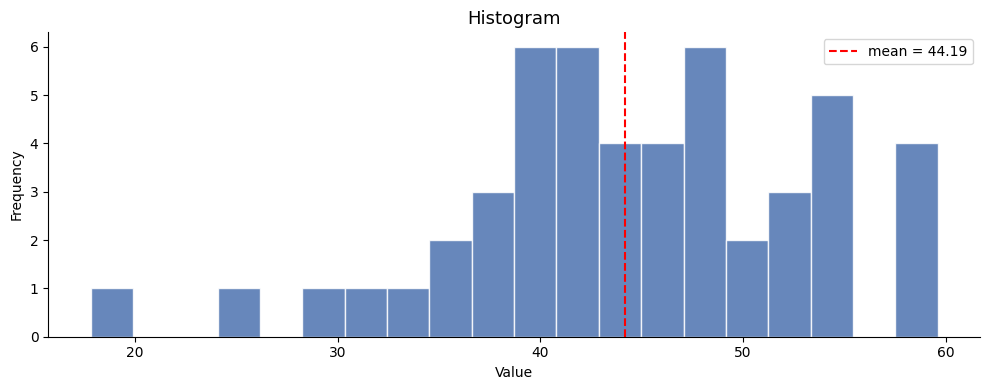

In [60]:
plot_histogram(temperature_score)

In [61]:
temperature_score = np.append(temperature_score, 999)

In [62]:
temperature_score

array([ 47.2,  40.2,  37.2,  50.2,  54.4,  53.4,  35.6,  41. ,  47.4,
        53.8,  39.2,  42.2,  33. ,  32. ,  52.2,  57.6,  43.2,  54. ,
        47.6,  37.6,  47.6,  59.4,  43.6,  59.6,  17.8,  52.2,  44.8,
        41. ,  45. ,  24.2,  41.8,  47.6,  58.8,  38.8,  36. ,  39. ,
        53.2,  47.2,  38.8,  49.2,  45. ,  53.6,  37. ,  40.8,  40. ,
        29.4,  47. ,  46.6,  44. ,  41.6, 999. ])

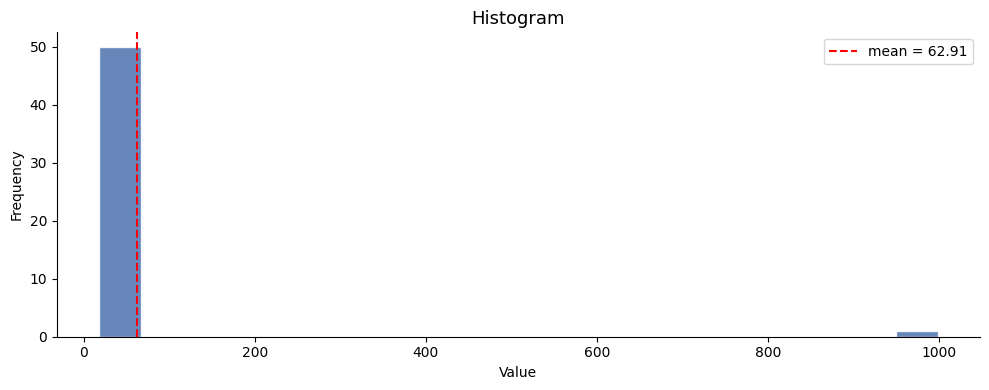

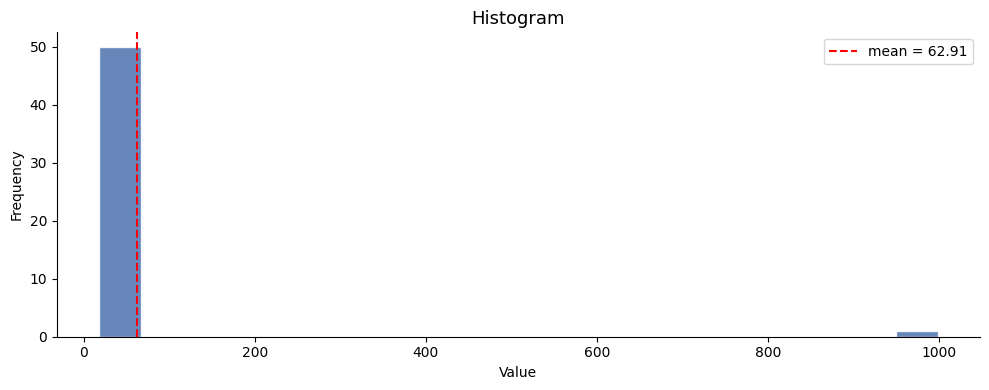

In [63]:
plot_histogram(temperature_score)